# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [1]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ==========================================================
# TASK 11
# Vision Transformer (ViT) From Scratch
# ==========================================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


In [4]:

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:


# ==========================================================
# Parameters
# ==========================================================

IMAGE_SIZE = 32
PATCH_SIZE = 4

CHANNELS = 3

NUM_CLASSES = 10

EMBED_DIM = 128

NUM_HEADS = 4

DEPTH = 4

MLP_DIM = 256

In [6]:


# ==========================================================
# Patch Embedding Layer
# ==========================================================

class PatchEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch_size = PATCH_SIZE

        self.num_patches = (IMAGE_SIZE // PATCH_SIZE) ** 2

        self.projection = nn.Conv2d(
            CHANNELS,
            EMBED_DIM,
            kernel_size=PATCH_SIZE,
            stride=PATCH_SIZE
        )

    def forward(self, x):

        x = self.projection(x)

        x = x.flatten(2)

        x = x.transpose(1,2)

        return x

In [7]:


# ==========================================================
# Multi Head Self Attention
# ==========================================================

class MultiHeadAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=EMBED_DIM,
            num_heads=NUM_HEADS,
            batch_first=True
        )

    def forward(self, x):

        output, weights = self.attention(
            x,
            x,
            x,
            need_weights=True
        )

        return output, weights

In [8]:


# ==========================================================
# Transformer Encoder Block
# ==========================================================

class TransformerBlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.norm1 = nn.LayerNorm(EMBED_DIM)

        self.attn = MultiHeadAttention()

        self.norm2 = nn.LayerNorm(EMBED_DIM)

        self.mlp = nn.Sequential(

            nn.Linear(EMBED_DIM, MLP_DIM),

            nn.GELU(),

            nn.Linear(MLP_DIM, EMBED_DIM)

        )

    def forward(self, x):

        attn_out, weights = self.attn(self.norm1(x))

        x = x + attn_out

        x = x + self.mlp(self.norm2(x))

        return x, weights

In [9]:


# ==========================================================
# Vision Transformer
# ==========================================================

class VisionTransformer(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch_embed = PatchEmbedding()

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(
            torch.randn(1,1,EMBED_DIM)
        )

        self.position = nn.Parameter(
            torch.randn(1,num_patches+1,EMBED_DIM)
        )

        self.blocks = nn.ModuleList(

            [TransformerBlock() for _ in range(DEPTH)]

        )

        self.norm = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Linear(EMBED_DIM, NUM_CLASSES)

    def forward(self, x):

        x = self.patch_embed(x)

        batch = x.shape[0]

        cls = self.cls_token.expand(batch,-1,-1)

        x = torch.cat([cls,x],dim=1)

        x = x + self.position

        attention = None

        for block in self.blocks:

            x, attention = block(x)

        x = self.norm(x)

        cls = x[:,0]

        out = self.head(cls)

        return out, attention

In [10]:


# ==========================================================
# Model
# ==========================================================

model = VisionTransformer().to(device)

print(model)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=128, bias=True)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:


# ==========================================================
# Dummy Image Batch
# ==========================================================

images = torch.randn(8,3,32,32).to(device)

labels = torch.randint(0,10,(8,)).to(device)

In [12]:


# ==========================================================
# Forward Pass
# ==========================================================

outputs, attention = model(images)

print("\nOutput Shape")

print(outputs.shape)


Output Shape
torch.Size([8, 10])


In [13]:


# ==========================================================
# Loss
# ==========================================================

criterion = nn.CrossEntropyLoss()

loss = criterion(outputs,labels)

print("\nLoss")

print(loss.item())


Loss
2.6150426864624023


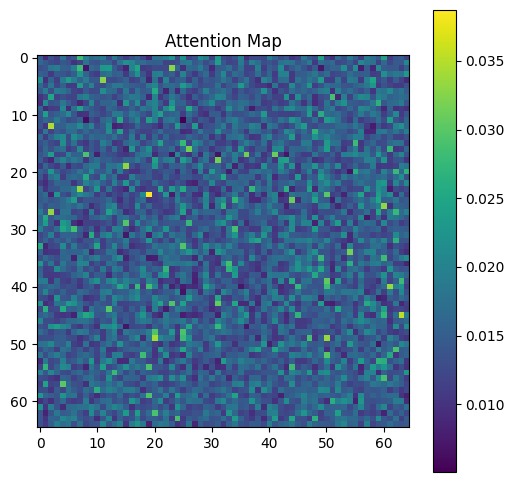


Task 11 Completed Successfully!


In [14]:


# ==========================================================
# Visualize Attention
# ==========================================================

attention = attention.detach().cpu()

plt.figure(figsize=(6,6))

plt.imshow(attention[0], cmap="viridis")

plt.colorbar()

plt.title("Attention Map")

plt.show()

print("\nTask 11 Completed Successfully!")